# Градиентный спуск

В данном задании необходимо реализовать метод градиентного спуска (функция gradient_descent) и
процедуру линейного поиска (метод line_search в класce LineSearchTool в модуле optimization).



**Алгоритм 1: Общая схема метода спуска**

**Вход:** Начальная точка $x_0$; максимальное число итераций $K$.

1. **for** $k \leftarrow 0$ **to** $K$ **do**
2. &emsp; **(Вызов оракула)** Вычислить $f(x_k)$, $\nabla f(x_k)$ и пр.
3. &emsp; **(Критерий остановки)** Если выполнен критерий остановки, то выход.
4. &emsp; **(Вычисление направления)** Вычислить направление спуска $d_k$.
5. &emsp; **(Линейный поиск)** Найти подходящую длину шага $\alpha_k$.
6. &emsp; **(Обновление)** $x_{k+1} \leftarrow x_k + \alpha_k d_k$.
7. **end for**

**Выход:** Последняя вычисленная точка $x_k$

In [16]:
import numpy as np
from numpy.linalg import LinAlgError
import scipy
from datetime import datetime
from collections import defaultdict
from scipy.special import expit
from scipy.optimize import line_search
from scipy.optimize._linesearch import scalar_search_wolfe2
from scipy.optimize import minimize_scalar
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm

**Критерий остановки**

Наиболее популярным критерием остановки является критерий, основанный на норме градиента: $\| \nabla f(x_k) \|_2^2 < \tilde{\varepsilon}$.  
Квадрат здесь ставят за тем, что для «хороших» функций невязка по функции $f(x_k) - f^*$ имеет тот же порядок, что $u = \| \nabla f(x_k) \|_2^2$, а не $\| \nabla f(x_k) \|_2^1$; например, если $\| \nabla f(x_k) \|_2 \sim 10^{-5}$, то $f(x_k) - f^* \sim 10^{-10}$.  
Наконец, для того, чтобы критерий не зависел от того, измеряется ли функция $f$ «в метрах» или «в километрах» (т. е. не изменялся при переходе от функции $f$ к функции $tf$, где $t > 0$), то имеет смысл использовать следующий относительный вариант критерия:  

$$\| \nabla f(x_k) \|_2^2 \leq \epsilon \| \nabla f(x_0) \|_2^2$$

где $\epsilon \in (0, 1)$ — заданная относительная точность. Таким образом, данный критерий остановки гарантирует, что метод уменьшит начальную невязку $\| \nabla f(x_0) \|_2$ в $\epsilon^{-1}$ раз. В этом задании Вам нужно будет во всех методах использовать этот критерий остановки.


**Линейный поиск**

Рассматривается функция  
$$\phi_k(\alpha) := f(x_k + \alpha d_k)$$


Заметим, что  
$$\phi_k'(\alpha) = \langle \nabla f(x_k + \alpha d_k), d_k \rangle $$

Поскольку $d_k$ является направлением спуска, то $\phi'(0) = \langle \nabla f(x_k), d_k \rangle < 0$.

Условием Армихо для $\alpha$ называется выполнение следующего неравенства:  
$$\phi_k(\alpha) \leq \phi_k(0) + c_1 \alpha \phi_k'(0)$$

где $c_1 \in (0, 0.5)$ - некоторая константа.

Для поиска точки $\alpha$, удовлетворяющей условию Армихо, обычно используют следующую процедуру - метод дробления шага (бэктрэкинг):


**Алгоритм 2: Метод дробления шага (бэктрэкинг)**

**Вход:** Функция $\phi_k : \mathbb{R}_+ \rightarrow \mathbb{R}$; начальное значение шага $\alpha_k^{(0)}$.

1. $\alpha \leftarrow \alpha_k^{(0)}$
2. **while** $\phi_k(\alpha) > \phi_k(0) + c_1 \alpha \phi_k'(0)$ **do**
3. &emsp; $\alpha \leftarrow \alpha/2$
4. **end while**

**Выход:** $\alpha$

«Адаптивный» метод подбора шага запоминает величину $\alpha_k$, найденную на текущей итерации и на следующей итерации начинает процедуру дробления с $\alpha_{k+1}^{(0)} := 2\alpha_k$. Исключение здесь составляют ньютоновские и квазиньютоновские методы - в этих методах процедуру дробления шага всегда нужно начинать с $\alpha_k^{(0)} := 1$.

Сильные условия Вульфа:
$$\phi_k(\alpha) \leq \phi(0) + c_1 \alpha \phi_k'(0)$$
$$| \phi_k'(\alpha)| \leq c_2 |\phi_k'(0)|
$$

Здесь $c_1 \in (0, 0.5), c_2 \in (c_1, 1)$.


*Рекомендация:* Для поиска точки, удовлетворяющей сильным условиям Вульфа,
воспользуйтесь библиотечной функцией scalar_search_wolfe2 из модуля scipy.optimize.linesearch. В ней начальная длина шага $\alpha_k^{(0)}$ автоматически выбирается равной 1.
Однако следует иметь в виду, что у этой библиотечной функции имеется один недостаток: она иногда не сходится и возвращает значение None.
Если библиотечный метод вернул None, то запустите процедуру дробления шага (бэктрекинг) для поиска точки, удовлетворяющей условию Армихо.
Для методов Brent и golden можно использовать scipy.optimize.minimize_scalar


In [17]:
class LineSearchTool(object):
    """
    Line search tool for adaptively tuning the step size of the algorithm.

    method : String containing 'Wolfe', 'Armijo', 'Constant', 'Brent' anvvvd 'Golden',
        Method of tuning step-size.
        Must be be one of the following strings:
            - 'Wolfe' -- enforce strong Wolfe conditions;
            - 'Armijo" -- adaptive Armijo rule;
            - 'Constant' -- constant step size;
            - 'Brent' -- Brent's method for exact line search;
            - 'Golden' -- golden section search for exact line search..
    kwargs :
        Additional parameters of line_search method:

        If method == 'Wolfe':
            c1, c2 : Constants for strong Wolfe conditions
            alpha_0 : Starting point for the backtracking procedure
                to be used in Armijo method in case of failure of Wolfe method.
        If method == 'Armijo':
            c1 : Constant for Armijo rule
            alpha_0 : Starting point for the backtracking procedure.
        If method == 'Constant':
            c : The step size which is returned on every step.
        If method == 'Brent' or 'Golden':
            bracket : Tuple (a, b) for the initial bracket interval for minimization.
                     If not provided, will be determined automatically.
            tol : Tolerance for termination (optional)
    """
    def __init__(self, method='Wolfe', **kwargs):
        self._method = method
        if self._method == 'Wolfe':
            self.c1 = kwargs.get('c1', 1e-4)
            self.c2 = kwargs.get('c2', 0.9)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Armijo':
            self.c1 = kwargs.get('c1', 1e-4)
            self.alpha_0 = kwargs.get('alpha_0', 1.0)
        elif self._method == 'Constant':
            self.c = kwargs.get('c', 1.0)
        elif self._method == 'Brent' or self._method == 'Golden':
            self.bracket = kwargs.get('bracket', None)
            self.tol = kwargs.get('tol', 1e-4)
        else:
            raise ValueError('Unknown method {}'.format(method))

    @classmethod
    def from_dict(cls, options):
        if type(options) != dict:
            raise TypeError('LineSearchTool initializer must be of type dict')
        return cls(**options)

    def to_dict(self):
        return self.__dict__

    def line_search(self, oracle, x_k, d_k, previous_alpha=None):
        """
        Finds the step size alpha for a given starting point x_k
        and for a given search direction d_k that satisfies necessary
        conditions for phi(alpha) = oracle.func(x_k + alpha * d_k).

        Parameters
        ----------
        oracle : BaseSmoothOracle-descendant object
            Oracle with .func_directional() and .grad_directional() methods implemented for computing
            function values and its directional derivatives.
        x_k : np.array
            Starting point
        d_k : np.array
            Search direction
        previous_alpha : float or None
            Starting point to use instead of self.alpha_0 to keep the progress from
             previous steps. If None, self.alpha_0, is used as a starting point.

        Returns
        -------
        alpha : float or None if failure
            Chosen step size
        """
        # TODO: Implement line search procedures for Armijo, Wolfe, Constant, Brent or Golden steps.
        def phi(alpha):
            return oracle.func(x_k + alpha * d_k)

        def phi_prime(alpha):
            return np.dot(oracle.grad(x_k + alpha * d_k), d_k)

        phi_0 = phi(0)
        phi_prime_0 = phi_prime(0)


        if previous_alpha is not None:
            alpha_init = previous_alpha
        else:
            alpha_init = self.alpha_0 if hasattr(self, 'alpha_0') else 1.0

        if self._method == 'Constant':
            return self.c

        elif self._method == 'Armijo':
            alpha = alpha_init

            while phi(alpha) > phi_0 + self.c1 * alpha * phi_prime_0:
                alpha /= 2.0
                if alpha < 1e-10:
                    return None

            return alpha


        elif self._method == 'Wolfe':
            try:
                alpha, _, _, _ = scalar_search_wolfe2(
                    phi, phi_prime, phi_0, phi_prime_0,
                    c1=self.c1, c2=self.c2
                )

                if alpha is not None and alpha > 0:
                    return alpha

            except Exception as e:
                # если ошибка, то Армихо
                print("ошибка в библиотеке, делаем Армихо")

            alpha = alpha_init
            while phi(alpha) > phi_0 + self.c1 * alpha * phi_prime_0:
                alpha /= 2.0
                if alpha < 1e-10:
                    return None

            return alpha

        elif self._method == 'Brent':
            bracket = self.bracket or (0, alpha_init * 2)
            result = minimize_scalar(phi, bracket=bracket, method='brent', tol=self.tol)
            return result.x if result.success else None

        elif self._method == 'Golden':
            bracket = self.bracket or (0, alpha_init * 2)
            result = minimize_scalar(phi, bracket=bracket, method='golden', tol=self.tol)
            return result.x if result.success else None

        else:
            raise ValueError('Unknown method {}'.format(self._method))
        return None


def get_line_search_tool(line_search_options=None):
    if line_search_options:
        if type(line_search_options) is LineSearchTool:
            return line_search_options
        else:
            return LineSearchTool.from_dict(line_search_options)
    else:
        return LineSearchTool()




Для реализации нужно использовать oracle, экземпляр класса-наследника BaseSmoothOracle.

**Оракул** - это абстрактный интерфейс, который предоставляет информацию о целевой функции в запрошенной точке по требованию алгоритма оптимизации.

Для целевой функции $ f: \mathbb{R}^n \rightarrow \mathbb{R} $ оракул реализует отображения:
- $ \text{func}(x) \mapsto f(x) $
- $ \text{grad}(x) \mapsto \nabla f(x) $
- $ \text{hess}(x) \mapsto \nabla^2 f(x) $


In [18]:
import time

def gradient_descent(oracle, x_0, tolerance=1e-5, max_iter=10000,
                     line_search_options=None, trace=False, display=False):
    """
    Gradient descent optimization method.

    Parameters
    ----------
    oracle : BaseSmoothOracle-descendant object
        Oracle with .func(), .grad() and .hess() methods implemented for computing
        function value, its gradient and Hessian respectively.
    x_0 : np.array
        Starting point for optimization algorithm
    tolerance : float
        Epsilon value for stopping criterion.
    max_iter : int
        Maximum number of iterations.
    line_search_options : dict, LineSearchTool or None
        Dictionary with line search options. See LineSearchTool class for details.
    trace : bool
        If True, the progress information is appended into history dictionary during training.
        Otherwise None is returned instead of history.
    display : bool
        If True, debug information is displayed during optimization.
        Printing format and is up to a student and is not checked in any way.

    Returns
    -------
    x_star : np.array
        The point found by the optimization procedure
    message : string
        "success" or the description of error:
            - 'iterations_exceeded': if after max_iter iterations of the method x_k still doesn't satisfy
                the stopping criterion.
            - 'computational_error': in case of getting Infinity or None value during the computations.
    history : dictionary of lists or None
        Dictionary containing the progress information or None if trace=False.
        Dictionary has to be organized as follows:
            - history['time'] : list of floats, containing time in seconds passed from the start of the method
            - history['func'] : list of function values f(x_k) on every step of the algorithm
            - history['grad_norm'] : list of values Euclidian norms ||g(x_k)|| of the gradient on every step of the algorithm
            - history['x'] : list of np.arrays, containing the trajectory of the algorithm. ONLY STORE IF x.size <= 2
    """
    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)
    
    start_time = time.time()
    grad_k = oracle.grad(x_k)
    
    initial_grad_norm_sq = np.linalg.norm(grad_k) ** 2
    prev_alpha = None
    
    if trace:
        cur_time = time.time() - start_time
        f_k = oracle.func(x_k)
        g_norm = np.linalg.norm(grad_k)
        history['time'].append(cur_time)
        history['func'].append(f_k)
        history['grad_norm'].append(g_norm)
        if x_k.size <= 2:
            history['x'].append(x_k.copy())
    
    for iter_num in range(max_iter):
        grad_k = oracle.grad(x_k)

        if np.any(~np.isfinite(grad_k)):
            return x_k, 'computational_error', history
        
        if np.linalg.norm(grad_k) ** 2 <= tolerance * initial_grad_norm_sq:
            break

        alpha = line_search_tool.line_search(oracle, x_k, -grad_k, previous_alpha=prev_alpha)

        if not (alpha and np.isfinite(alpha) and alpha > 0):
            return x_k, 'computational_error', history
        
        x_k = x_k - alpha * grad_k
        prev_alpha = alpha * 2  

        if trace:
            cur_time = time.time() - start_time
            f_k = oracle.func(x_k)
            g_norm = np.linalg.norm(oracle.grad(x_k))
            history['time'].append(cur_time)
            history['func'].append(f_k)
            history['grad_norm'].append(g_norm)
            if x_k.size <= 2:
                history['x'].append(x_k.copy())
        
        if display:
            print(f"Iter {iter_num}: f={f_k:.6f}, ||g||={g_norm:.6f}, a={alpha:.6f}")
    
    if trace and (not history['time'] or abs(history['time'][-1] - (time.time() - start_time)) > 1e-6):
        cur_time = time.time() - start_time
        f_k = oracle.func(x_k)
        g_norm = np.linalg.norm(oracle.grad(x_k))
        history['time'].append(cur_time)
        history['func'].append(f_k)
        history['grad_norm'].append(g_norm)
        if x_k.size <= 2:
            history['x'].append(x_k.copy())
    
    return x_k, 'success', history

# Матричное дифференцирование двухклассовой логистической регрессии

Получите функцию потерь логистической регрессии с L2-регуляризацией в матрично-векторной форме, а также формулы для градиента и гессиана этой функции. Можно использовать поэлементные функции, но без явного суммирования. Ответ запишите в ячейке ниже, решение не нужно

**Исходные данные:**
- Матрица признаков $A \in \mathbb{R}^{m \times n}$
- Вектор меток $b \in \mathbb{R}^{m}$, где $b_i \in \{-1, +1\}$
- Вектор весов $x \in \mathbb{R}^{n}$
- Коэффициент регуляризации $\lambda > 0$

**Исходная функция в скалярной форме:**
$$
\min_{x \in \mathbb{R}^n} \left\{ \frac{1}{m} \sum_{i=1}^m \ln{\left(1 + \exp{(-b_i \langle a_i, x \rangle)}\right)} + \frac{\lambda}{2} \|x\|_2^2 \right\}
$$

*Примечание: для обозначения поэлементных операций можно использовать обозначение $\odot$ (произведение Адамара).*

Напишите тут свой ответ:



`Ваш ответ здесь`



Реализуйте оракул логистической регрессии (класc LogRegL20racle). Также доделате реализацию вспомогательной функции create_log_reg_oracle.

**Замечание:** Реализация оракула должна быть полностью векторизованной, т. е. код не должен содержать никаких циклов.

**Замечание:** Ваш код должен поддерживать как плотные матрицы A типа np.array, так и разреженные типа scipy.sparse.csr_matrix.

**Замечание:** Нигде в промежуточных вычислениях не стоит вычислять значение $\exp(−b_i ⟨a_i , x⟩)$, иначе может произойти переполнение. Вместо этого следует напрямую вычислять необходимые величины с помощью специализированных для этого функций: *np.logaddexp* для $\ln(1+\exp(·))$ и *scipy.special.expit* для $1/(1 + \exp(·))$.

In [19]:
import numpy as np
from scipy import sparse
from scipy.special import expit 

class BaseSmoothOracle(object):
    """
    Base class for implementation of oracles.
    """
    def func(self, x):
        """
        Computes the value of function at point x.
        """
        raise NotImplementedError('Func oracle is not implemented.')

    def grad(self, x):
        """
        Computes the gradient at point x.
        """
        raise NotImplementedError('Grad oracle is not implemented.')

    def hess(self, x):
        """
        Computes the Hessian matrix at point x.
        """
        raise NotImplementedError('Hessian oracle is not implemented.')

    def func_directional(self, x, d, alpha):
        """
        Computes phi(alpha) = f(x + alpha*d).
        """
        return np.squeeze(self.func(x + alpha * d))

    def grad_directional(self, x, d, alpha):
        """
        Computes phi'(alpha) = (f(x + alpha*d))'_{alpha}
        """
        return np.squeeze(self.grad(x + alpha * d).dot(d))

class LogRegL2Oracle(BaseSmoothOracle):
    """
    Oracle for logistic regression with l2 regularization:
         func(x) = 1/m sum_i log(1 + exp(-b_i * a_i^T x)) + regcoef / 2 ||x||_2^2.

    Parameters
    ----------
        matvec_Ax : function
            Computes matrix-vector product Ax, where x is a vector of size n.
        matvec_ATx : function of x
            Computes matrix-vector product A^Tx, where x is a vector of size m.
        matmat_ATsA : function
            Computes matrix-matrix-matrix product A^T * Diag(s) * A,
    """
    def __init__(self, matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef):
        self.matvec_Ax = matvec_Ax
        self.matvec_ATx = matvec_ATx
        self.matmat_ATsA = matmat_ATsA
        self.b = b
        self.regcoef = regcoef
        self.m = len(b)

    def func(self, x):
        """
        Computes the value of function at point x.
        f(x) = 1/m * sum(log(1 + exp(-b_i * <a_i, x>))) + regcoef/2 * ||x||^2
        """
        z = self.matvec_Ax(x)  # A x
        log_terms = np.logaddexp(0, -self.b * z)
        log_loss = np.sum(log_terms) / self.m
        reg_loss = (self.regcoef / 2) * np.dot(x, x)
        return log_loss + reg_loss

    def grad(self, x):
        """
        Computes the gradient at point x:
        grad f(x) = -1/m * A^T (b * sigma(-b * (A x))) + regcoef * x
        где sigma(t) = 1/(1 + exp(-t))
        """
        z = self.matvec_Ax(x)  # A x
        u = -self.b * z
        sigma_u = expit(u)
        grad_log = - (1 / self.m) * self.matvec_ATx(self.b * sigma_u)
        grad_reg = self.regcoef * x
        return grad_log + grad_reg

    def hess(self, x):
        """
        Computes the Hessian matrix at point x:
        H = 1/m * A^T * Diag(s) * A + regcoef * I
        где s_i = sigma(-b_i * z_i) * (1 - sigma(-b_i * z_i))
        """
        z = self.matvec_Ax(x)  # A x
        u = -self.b * z
        sigma_u = expit(u)
        s = sigma_u * (1 - sigma_u)
        hess_log = (1 / self.m) * self.matmat_ATsA(s)
        n = x.shape[0]
        hess_reg = self.regcoef * np.eye(n)
        return hess_log + hess_reg



def create_log_reg_oracle(A, b, regcoef):
    """
    Auxiliary function for creating logistic regression oracles.
    Supports both dense and sparse matrices.
    """
    if sparse.issparse(A):
        # Для разреженных матриц
        matvec_Ax = lambda x: A.dot(x)
        matvec_ATx = lambda x: A.T.dot(x)

        def matmat_ATsA(s):
            """Вычисляет A^T * Diag(s) * A для разреженной матрицы"""
            D = sparse.diags(s)
            return A.T.dot(D).dot(A)

    else:

        matvec_Ax = lambda x: A.dot(x)
        matvec_ATx = lambda x: A.T.dot(x)

        def matmat_ATsA(s):
            """Вычисляет A^T * Diag(s) * A для плотной матрицы эффективно"""
            return (A * s[:, np.newaxis]).T.dot(A)


    return LogRegL2Oracle(matvec_Ax, matvec_ATx, matmat_ATsA, b, regcoef)

# Эксперимент 1: Траектория градиентного спуска на квадратичной функции

Проанализируйте траекторию градиентного спуска для нескольких квадратичных функций: придумайте две-три квадратичные двумерные функции, на которых работа метода будет отличаться, нарисуйте графики с линиями уровня функций и траекториями методов.

Попробуйте ответить на следующий вопрос: Как отличается поведение метода в зависимости от числа обусловленности функции, выбора начальной точки и стратегии выбора шага (константная стратегия, Армихо, Вульф)?

Для рисования линий уровня можете воспользоваться функцией $\texttt{plot_levels}$, а для рисования траекторий - $\texttt{plot_trajectory}$ или реализовать свои.

Также обратите внимание, что оракул квадратичной функции $\texttt{QuadraticOracle}$ уже реализован. Он реализует функцию
$$
f(x) = \frac{1}{2}\langle Ax,x\rangle - \langle b,x\rangle,
$$
где $A \in \mathbb{S}_{++}^n, b \in \mathbb{R}^n$.

In [20]:
class QuadraticOracle(BaseSmoothOracle):
    """
    Oracle for quadratic function:
       func(x) = 1/2 x^TAx - b^Tx.
    """

    def __init__(self, A, b):
        if not scipy.sparse.isspmatrix_dia(A) and not np.allclose(A, A.T):
            raise ValueError('A should be a symmetric matrix.')
        self.A = A
        self.b = b

    def func(self, x):
        return 0.5 * np.dot(self.A.dot(x), x) - self.b.dot(x)

    def grad(self, x):
        return self.A.dot(x) - self.b

    def hess(self, x):
        return self.A

In [23]:
def plot_levels(func, xrange=None, yrange=None, levels=None):
    """
    Plotting the contour lines of the function.

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> plot_levels(oracle.func)
    """
    if xrange is None:
        xrange = [-6, 6]
    if yrange is None:
        yrange = [-5, 5]
    if levels is None:
        levels = [0, 0.25, 1, 4, 9, 16, 25]

    x = np.linspace(xrange[0], xrange[1], 100)
    y = np.linspace(yrange[0], yrange[1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros(X.shape)
    for i in range(Z.shape[0]):
        for j in range(Z.shape[1]):
            Z[i, j] = func(np.array([X[i, j], Y[i, j]]))

    CS = plt.contour(X, Y, Z, levels=levels, colors='k', linewidth=4.0)
    plt.clabel(CS, inline=1, fontsize=8)
    plt.grid()


def plot_trajectory(func, history, fit_axis=False, label=None):
    """
    Plotting the trajectory of a method.
    Use after plot_levels(...).

    Example:
    --------
    >> oracle = oracles.QuadraticOracle(np.array([[1.0, 2.0], [2.0, 5.0]]), np.zeros(2))
    >> [x_star, msg, history] = optimization.gradient_descent(oracle, np.array([3.0, 1.5], trace=True)
    >> plot_levels(oracle.func)
    >> plot_trajectory(oracle.func, history['x'])
    """
    x_values, y_values = zip(*history)
    plt.plot(x_values, y_values, '-v', linewidth=5.0, ms=12.0,
             alpha=1.0, c='r', label=label)

    # Tries to adapt axis-ranges for the trajectory:
    if fit_axis:
        xmax, ymax = np.max(x_values), np.max(y_values)
        COEF = 1.5
        xrange = [-xmax * COEF, xmax * COEF]
        yrange = [-ymax * COEF, ymax * COEF]
        plt.xlim(xrange)
        plt.ylim(yrange)

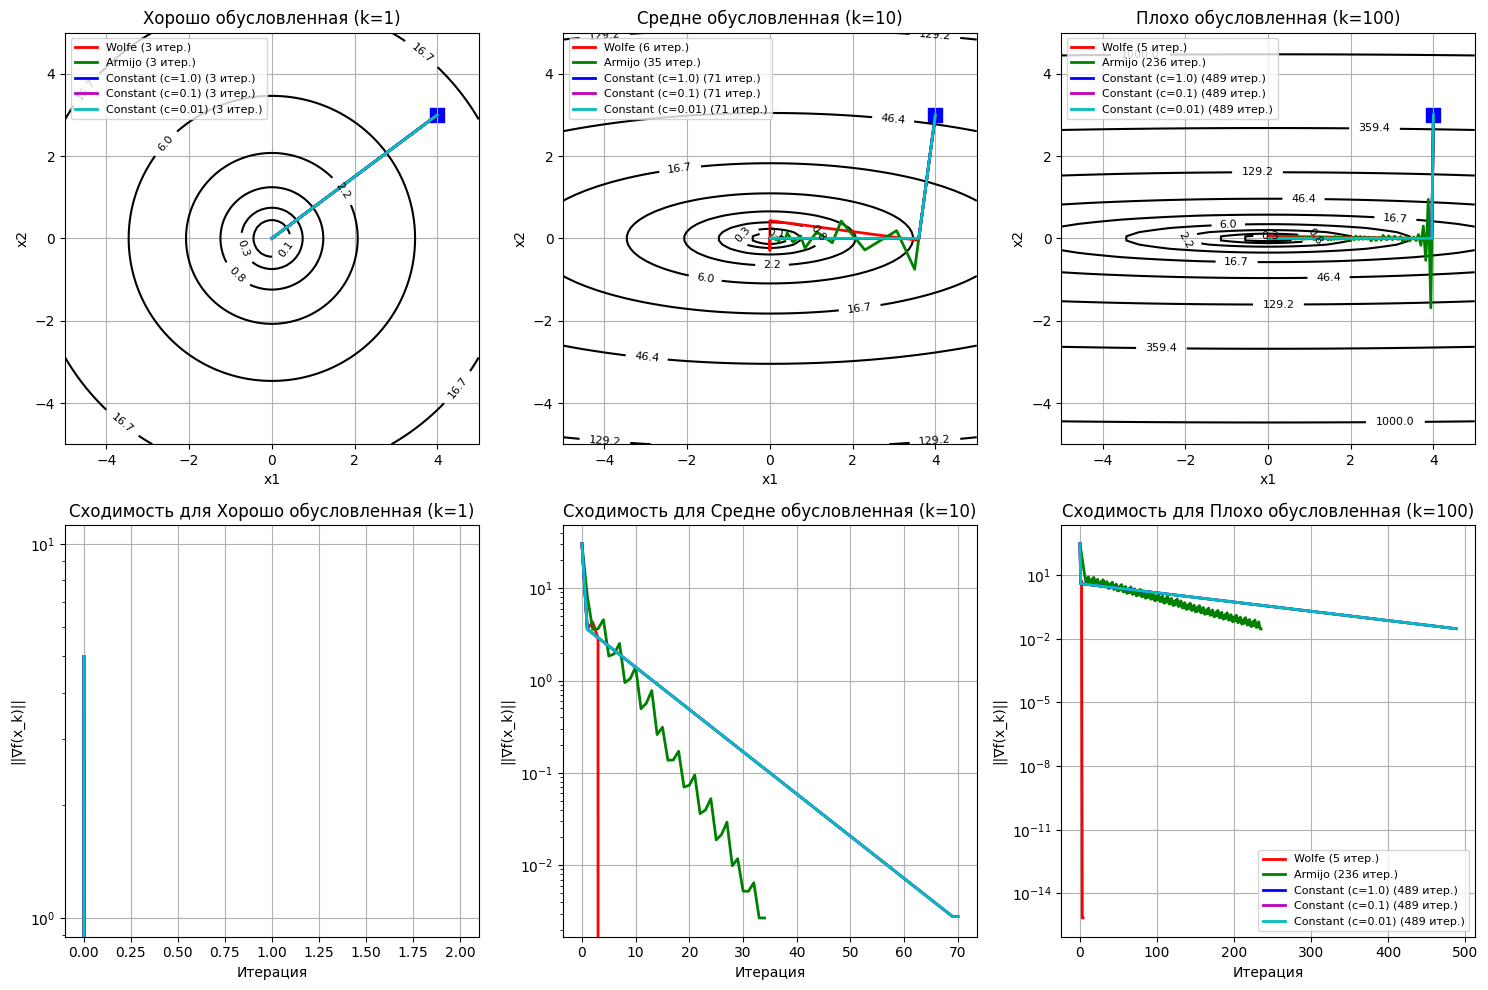

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import time

A1 = np.array([[1.0, 0.0], [0.0, 1.0]])
b1 = np.array([0.0, 0.0])
oracle1 = QuadraticOracle(A1, b1)

A2 = np.array([[1.0, 0.0], [0.0, 10.0]])
b2 = np.array([0.0, 0.0])
oracle2 = QuadraticOracle(A2, b2)

A3 = np.array([[1.0, 0.0], [0.0, 100.0]])
b3 = np.array([0.0, 0.0])
oracle3 = QuadraticOracle(A3, b3)

x0 = np.array([4.0, 3.0])

line_search_strategies = [
    {'method': 'Wolfe', 'label': 'Wolfe'},
    {'method': 'Armijo', 'label': 'Armijo'},
    {'method': 'Constant', 'c': 1.0, 'label': 'Constant (c=1.0)'},  # Для k=1
    {'method': 'Constant', 'c': 0.1, 'label': 'Constant (c=0.1)'},  # Для k=10
    {'method': 'Constant', 'c': 0.01, 'label': 'Constant (c=0.01)'}  # Для k=100
]

results = []
oracles = [oracle1, oracle2, oracle3]
titles = ['Хорошо обусловленная (k=1)', 'Средне обусловленная (k=10)', 'Плохо обусловленная (k=100)']

for i, oracle in enumerate(oracles):
    oracle_results = []
    for strategy in line_search_strategies:
        if strategy['method'] == 'Constant':
            if i == 0: 
                options = {'method': 'Constant', 'c': 1.0}
            elif i == 1:
                options = {'method': 'Constant', 'c': 0.1}
            else:
                options = {'method': 'Constant', 'c': 0.01}
        else:
            options = strategy

        x_star, msg, history = gradient_descent(
            oracle, x0, tolerance=1e-8, max_iter=1000,
            line_search_options=options,
            trace=True
        )
        oracle_results.append((strategy['label'], history, x_star, len(history['time'])))
    results.append((titles[i], oracle_results))


plt.figure(figsize=(15, 10))

for i, (title, oracle_results) in enumerate(results):
    plt.subplot(2, 3, i+1)
    plot_levels(oracles[i].func, xrange=[-5, 5], yrange=[-5, 5], levels=np.logspace(-1, 3, 10))

    colors = ['r', 'g', 'b', 'm', 'c']
    for j, (label, history, x_star, iterations) in enumerate(oracle_results):
        trajectory = np.array(history['x'])
        plt.plot(trajectory[:, 0], trajectory[:, 1], '-', color=colors[j], linewidth=2.0,
                 label=f'{label} ({iterations} итер.)')

    plt.scatter([x0[0]], [x0[1]], c='b', s=100, marker='s')
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend(fontsize=8)

    plt.subplot(2, 3, i+4)
    for j, (label, history, x_star, iterations) in enumerate(oracle_results):
        if 'grad_norm' in history:
            plt.semilogy(history['grad_norm'], '-', color=colors[j], linewidth=2.0,
                        label=f'{label} ({iterations} итер.)')

    plt.xlabel('Итерация')
    plt.ylabel('||∇f(x_k)||')
    plt.title(f'Сходимость для {title}')
    plt.grid(True)
    if i == 2:
        plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

**ИТОГ**

Рост числа обусловленности матрицы негативно сказывается на скорости работы всех алгоритмов, но в разной степени.

Метод с постоянным шагом: Крайне неустойчив. Его сходимость резко ухудшается и может быть потеряна при большой обусловленности.
Метод Армихо: Замедляется с увеличением обусловленности, но остается значительно быстрее и надежнее метода с константным шагом.
Метод Вульфа: Сходимость почти не страдает от ухудшения обусловленности, обеспечивая стабильно высокую скорость

# Эксперимент 2: Зависимость числа итераций градиентного спуска от числа обусловленности и размерности пространства

Исследуйте, как зависит число итераций, необходимое градиентному спуску для сходимости, от следующих двух параметров:
1) числа обусловленности $k \geq 1$ оптимизируемой функции и
2) размерности пространства $n$ оптимизируемых переменных.

Для этого для заданных параметров $n$ и $k$ сгенерируйте случайным образом квадратичную задачу размера $n$ с числом обусловленности $k$ и запустите на ней градиентный спуск с некоторой фиксированной требуемой точностью. Замерьте число итераций $T(n,k)$, которое потребовалось сделать методу до сходимости (успешному выходу по критерию остановки).

**Рекомендация:** Проще всего сгенерировать случайную квадратичную задачу размера $n$ с заданным числом обусловленности $k$ следующим образом. В качестве матрицы $A \in S_{n}^{++}$ удобно взять просто диагональную матрицу $A = \text{Diag}(a)$, у которой диагональные элементы сгенерированы случайно в пределах $[1,k]$, причем $\min(a) = 1$, $\max(a) = k$. В качестве вектора $b \in \mathbb{R}^n$ можно взять вектор со случайными элементами. Диагональные матрицы удобно рассматривать, поскольку с ними можно эффективно работать даже при больших значениях $n$. Рекомендуется хранить матрицу $A$ в формате разреженной диагональной матрицы (см. $\texttt{scipy.sparse.diags}$).

Зафиксируйте некоторое значение размерности $n$. Переберите различные числа обусловленности $k$ по сетке и построите график зависимости $T(k,n)$ от $k$. Поскольку каждый раз квадратичная задача генерируется случайным образом, то повторите этот эксперимент несколько раз. В результате для фиксированного значения $n$ у Вас должно получиться целое семейство кривых зависимости $T(k,n)$ от $k$. Нарисуйте все эти кривые одним и тем же цветом для наглядности (например, красным).

Теперь увеличьте значение $n$ и повторите эксперимент снова. Вы должны получить новое семейство кривых $T(n',k)$ против $k$. Нарисуйте их все одним и тем же цветом, но отличным от предыдущего (например, синим).


Повторите эту процедуру несколько раз для других значений $n$. В итоге должно получиться несколько разных семейств кривых - часть красных (соответствующих одному значению $n$), часть синих (соответствующих другому значению $n$), часть зеленых и т. д.

Обратите внимание, что значения размерности $n$ имеет смысл перебирать по логарифмической сетке (например, $n = 10$, $n = 100$, $n = 1000$ и т. д.).

Какие выводы можно сделать из полученной картинки?



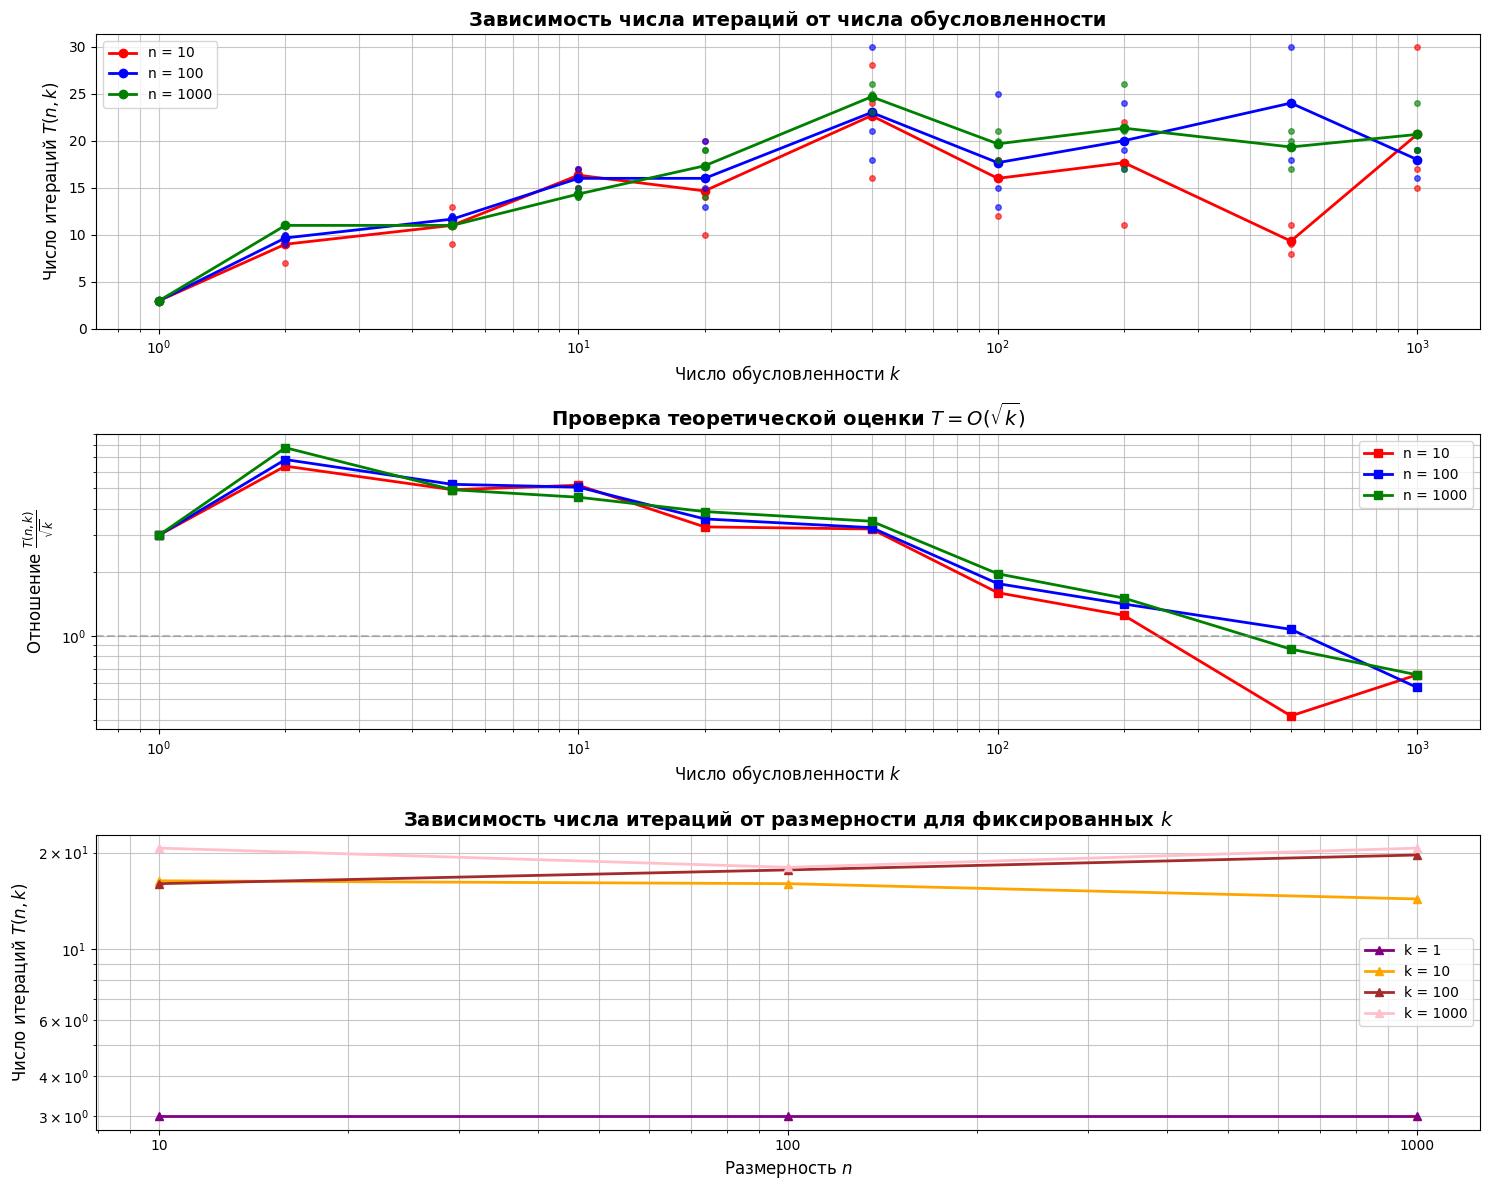

In [37]:
def generate_quadratic_task(n, k):
    if n == 1:
        diag = np.array([1.0])
    else:
        random_vals = np.random.uniform(1, k, n-2)
        diag = np.concatenate(([1.0, k], random_vals))
        np.random.shuffle(diag)
    
    A = np.diag(diag)
    b = np.random.randn(n)
    oracle = QuadraticOracle(A, b)
    x0 = np.random.randn(n) * 5
    
    return oracle, x0

def measure_iterations(n, k, repeats=3, tolerance=1e-5, max_iter=5000):
    iterations_list = []
    
    for i in range(repeats):
        try:
            oracle, x0 = generate_quadratic_task(n, k)
            _, msg, history = gradient_descent(
                oracle, x0, 
                tolerance=tolerance, 
                max_iter=max_iter,
                line_search_options={'method': 'Wolfe'},
                trace=True,
                display=False
            )
            
            if msg == 'success':
                iterations = len(history['time'])
            else:
                iterations = max_iter
            
            iterations_list.append(iterations)
            
        except Exception as e:
            iterations_list.append(max_iter)
    
    return iterations_list

dimensions = [10, 100, 1000]
k_values = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000]
repeats = 3
results = {n: {} for n in dimensions}

for n in dimensions:
    for k in k_values:
        iterations = measure_iterations(n, k, repeats=repeats, max_iter=2000)
        results[n][k] = iterations


plt.figure(figsize=(15, 12))


plt.subplot(3, 1, 1)
colors = {10: 'red', 100: 'blue', 1000: 'green'}

for n in dimensions:
    k_list = np.array(list(results[n].keys()))
    avg_iterations = np.array([np.mean(results[n][k]) for k in k_list])
    
    for k in k_list:
        iterations = results[n][k]
        for iter_count in iterations:
            plt.semilogx(k, iter_count, color=colors[n], marker='o', 
                        linestyle='', alpha=0.6, markersize=4)
    
    plt.semilogx(k_list, avg_iterations, 
                color=colors[n], linestyle='-', 
                linewidth=2, marker='o', markersize=6,
                label=f'n = {n}')

plt.xlabel('Число обусловленности $k$', fontsize=12)
plt.ylabel('Число итераций $T(n,k)$', fontsize=12)
plt.title('Зависимость числа итераций от числа обусловленности', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.7)
plt.legend(fontsize=10)
plt.ylim(bottom=0)

plt.subplot(3, 1, 2)

for n in dimensions:
    k_list = np.array(list(results[n].keys()))
    avg_iterations = np.array([np.mean(results[n][k]) for k in k_list])
    ratio = avg_iterations / np.sqrt(k_list)
    
    plt.loglog(k_list, ratio, 
               color=colors[n], linestyle='-', 
               linewidth=2, marker='s', markersize=6,
               label=f'n = {n}')

plt.xlabel('Число обусловленности $k$', fontsize=12)
plt.ylabel('Отношение $\\frac{T(n,k)}{\\sqrt{k}}$', fontsize=12)
plt.title('Проверка теоретической оценки $T = O(\\sqrt{k})$', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.7)
plt.legend(fontsize=10)
plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)

plt.subplot(3, 1, 3)


selected_k = [1, 10, 100, 1000]
colors_k = {1: 'purple', 10: 'orange', 100: 'brown', 1000: 'pink'}

for k in selected_k:
    n_list = np.array(dimensions)
    avg_iterations = np.array([np.mean(results[n][k]) for n in dimensions])
    
    plt.loglog(n_list, avg_iterations, 
               color=colors_k[k], linestyle='-', 
               linewidth=2, marker='^', markersize=6,
               label=f'k = {k}')

plt.xlabel('Размерность $n$', fontsize=12)
plt.ylabel('Число итераций $T(n,k)$', fontsize=12)
plt.title('Зависимость числа итераций от размерности для фиксированных $k$', fontsize=14, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.7)
plt.legend(fontsize=10)
plt.xticks(dimensions, [str(n) for n in dimensions])

plt.tight_layout()
plt.show()

Судя по графикам, зависимость прямо пропорциональная.

# Задача 1: Обоснование константного шага для градиентного спуска

Рассмотрим квадратичную функцию $f(x) = \frac{1}{2}\langle Ax, x\rangle - \langle b, x\rangle$, где $A \in \mathbb{S}_{++}^n$,

Пусть
$
A = \begin{pmatrix}
5 & 1 \\
1 & 3
\end{pmatrix}, \quad
b = \begin{pmatrix}
1 \\ 2
\end{pmatrix}, \quad
x_0 = \begin{pmatrix}
0 \\ 0
\end{pmatrix}
$

Предъявите конкретное значение константного шага $\alpha$, гарантирующее сходимость градиентного спуска для данной функции, и строго обоснуйте свой выбор.


# Эксперимент 3: Стратегия выбора длины шага в градиентном спуске

Исследовать, как зависит поведение метода от стратегии подбора шага: константный шаг (попробовать различные значения), бэктрэкинг (попробовать различные константы $c$), условия Вульфа (попробовать различные параметры $c_2$), метод Брента и метод золотого сечения.

Рассмотрите квадратичную функцию и логистическую регрессию с модельными данными (сгенерированными случайно). (Следует рассматривать матрицы размерностью m, n = 10000, 8000, можно также рассмотреть и другие варианты)

Запустите для этих функций градиентный спуск с разными стратегиями выбора шага из одной и той же начальной точки.

Нарисуйте кривые сходимости (относительная невязка по функции в логарифмической шкале против числа итераций — для квадратичной функции, относительный квадрат нормы градиента в логарифмической шкале против числа итераций — для логистической регрессии) для разных стратегий на одном графике.

Попробуйте разные начальные точки. Ответьте на вопрос: Какая стратегия выбора шага является самой лучшей?



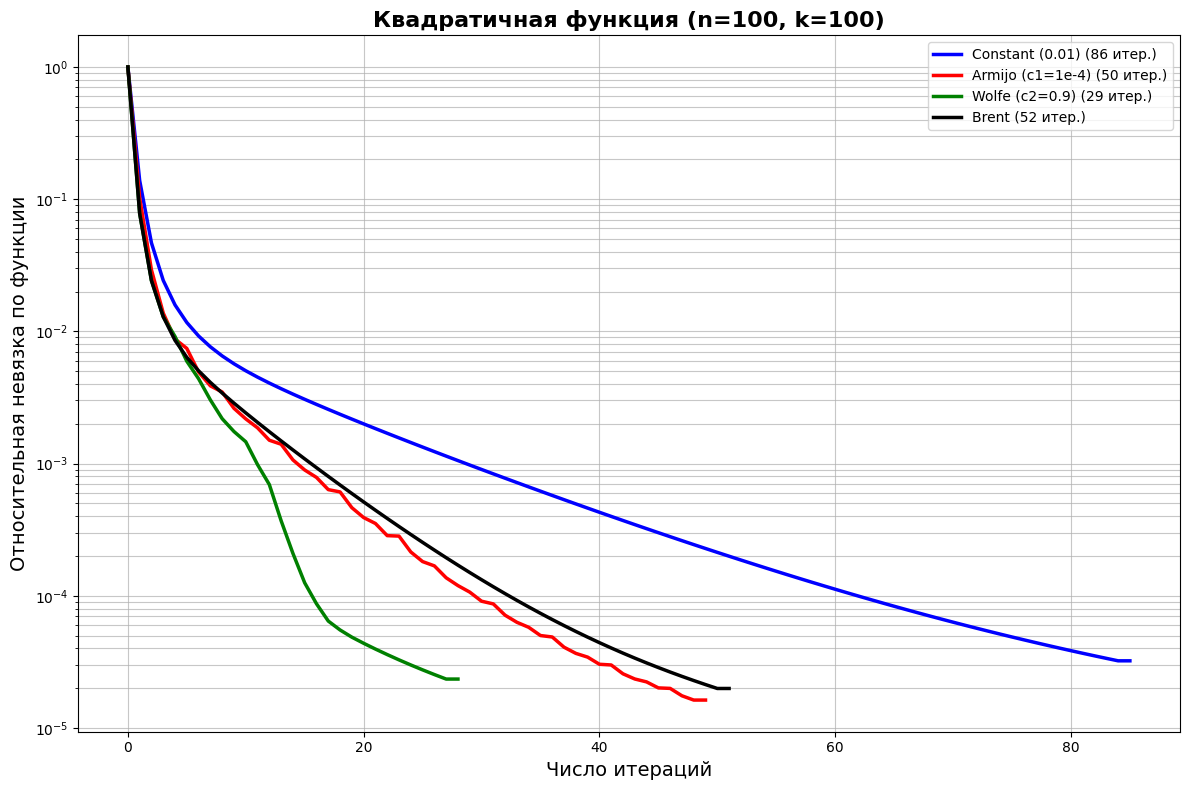

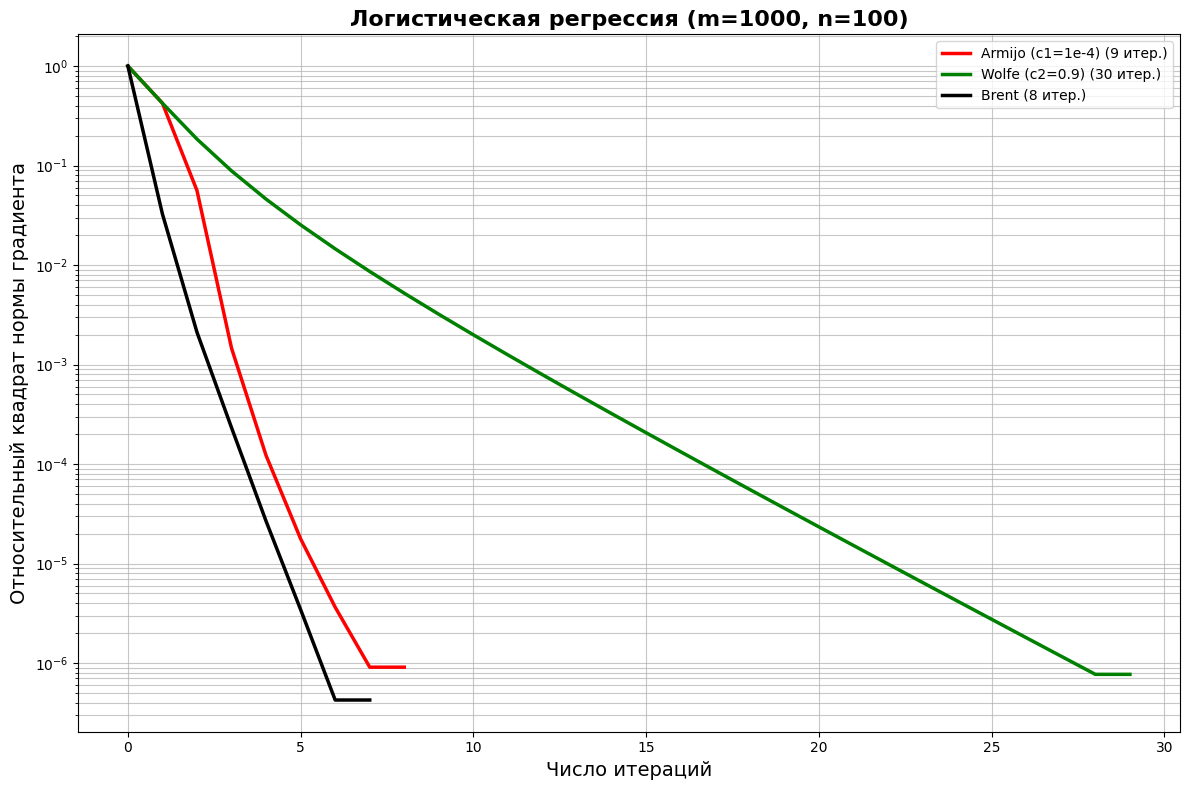

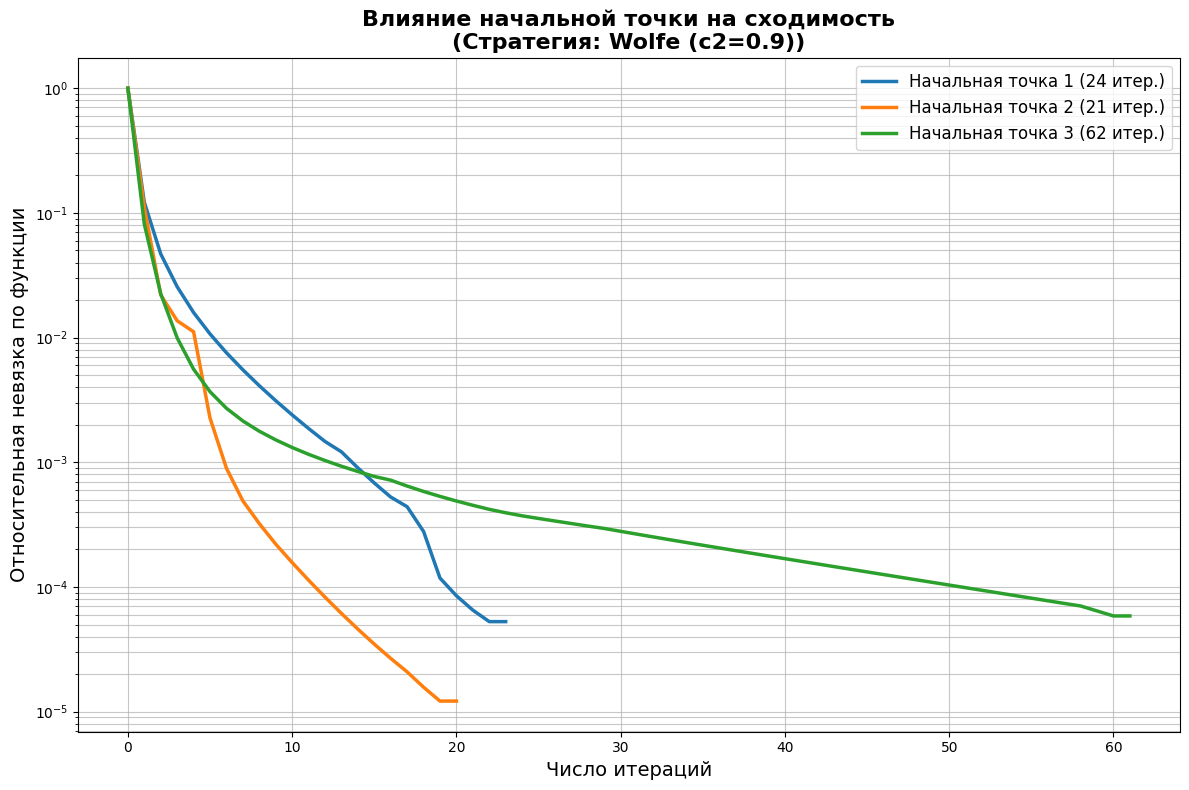

In [41]:
def generate_quadratic_problem(n, k):
    diag = np.random.uniform(1, k, max(0, n-2))
    diag = np.concatenate(([1.0, k], diag)) if n > 1 else np.array([1.0])
    np.random.shuffle(diag)
    return QuadraticOracle(np.diag(diag), np.random.randn(n))

def generate_logistic_data(m, n):
    X = np.random.randn(m, n)
    y = np.sign(X.dot(np.random.randn(n)) + 0.1 * np.random.randn(m))
    y[y == 0] = 1
    return X, y

def run_experiment(oracle, x0, strategies, max_iter=200, tol=1e-6):
    results = {}
    for name, opts in strategies.items():
        try:
            _, msg, hist = gradient_descent(oracle, x0.copy(), tol, max_iter, opts, True, False)
            if msg == 'success':
                results[name] = {'history': hist, 'iterations': len(hist['time']), 'success': True}
        except: pass
    return results

def plot_convergence(results, oracle, x0, title, is_quad=False, f_star=None):
    plt.figure(figsize=(12, 8))
    colors = {'Constant': 'blue', 'Armijo': 'red', 'Wolfe': 'green', 'Brent': 'black', 'Golden': 'yellow'}
    
    for name, res in results.items():
        if not res['success']: continue
        hist = res['history']
        color = next((colors[k] for k in colors if k in name), '#999999')
        
        if is_quad:
            rel_err = (np.array(hist['func']) - f_star) / (oracle.func(x0) - f_star)
            y = np.maximum(rel_err, 1e-15)
            ylabel = 'Относительная невязка по функции'
        else:
            grad_sq = np.array(hist['grad_norm']) ** 2
            y = grad_sq / grad_sq[0]
            ylabel = 'Относительный квадрат нормы градиента'
        
        plt.semilogy(range(len(y)), y, color=color, linewidth=2.5, label=f'{name} ({len(y)} итер.)')
    
    plt.xlabel('Число итераций', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.title(title, fontsize=16, fontweight='bold')
    plt.grid(True, which="both", ls="-", alpha=0.7)
    plt.legend(fontsize=10)
    plt.tight_layout()
    return plt.gcf()


oracle_quad = generate_quadratic_problem(100, 100)
x0_quad = np.random.randn(100) * 5
x_star, _, _ = gradient_descent(oracle_quad, x0_quad.copy(), 1e-10, 10000, {'method': 'Wolfe'}, True)
f_star = oracle_quad.func(x_star)

strategies_quad = {
    'Constant (0.1)': {'method': 'Constant', 'c': 0.1},
    'Constant (0.01)': {'method': 'Constant', 'c': 0.01},
    'Armijo (c1=1e-4)': {'method': 'Armijo', 'c1': 1e-4, 'alpha_0': 1.0},
    'Wolfe (c2=0.9)': {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9, 'alpha_0': 1.0},
    'Brent': {'method': 'Brent', 'tol': 1e-4}
}

X, y = generate_logistic_data(1000, 100)
oracle_log = create_log_reg_oracle(X, y, 0.1)
x0_log = np.random.randn(100) * 0.1

strategies_log = {
    'Constant (0.1)': {'method': 'Constant', 'c': 0.1},
    'Armijo (c1=1e-4)': {'method': 'Armijo', 'c1': 1e-4, 'alpha_0': 1.0},
    'Wolfe (c2=0.9)': {'method': 'Wolfe', 'c1': 1e-4, 'c2': 0.9, 'alpha_0': 1.0},
    'Brent': {'method': 'Brent', 'tol': 1e-4}
}


results_quad = run_experiment(oracle_quad, x0_quad, strategies_quad)
fig1 = plot_convergence(results_quad, oracle_quad, x0_quad, 'Квадратичная функция (n=100, k=100)', True, f_star)
plt.show()

results_log = run_experiment(oracle_log, x0_log, strategies_log)
fig2 = plot_convergence(results_log, oracle_log, x0_log, 'Логистическая регрессия (m=1000, n=100)', False)
plt.show()

initial_points = [np.random.randn(100) * scale for scale in [1, 5, 10]]
best_strategy = 'Wolfe (c2=0.9)'
plt.figure(figsize=(12, 8))

for i, x0 in enumerate(initial_points):
    res = run_experiment(oracle_quad, x0, {best_strategy: strategies_quad[best_strategy]})
    if best_strategy in res:
        hist = res[best_strategy]['history']
        rel_err = (np.array(hist['func']) - f_star) / (oracle_quad.func(x0) - f_star)
        plt.semilogy(range(len(rel_err)), np.maximum(rel_err, 1e-15), linewidth=2.5, 
                    label=f'Начальная точка {i+1} ({len(rel_err)} итер.)')

plt.xlabel('Число итераций', fontsize=14)
plt.ylabel('Относительная невязка по функции', fontsize=14)
plt.title(f'Влияние начальной точки на сходимость\n(Стратегия: {best_strategy})', fontsize=16, fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Лучше всего работают метод Вульфа и Армихо`

# Метод Нютона

Реализовать метод Ньютона (функция newton).

$$
x_{k+1} = x_k - \alpha_k \left[ \nabla^2 f(x_k) \right]^{-1} \nabla f(x_k)
$$

Для метода Ньютона очень важно использовать единичный шаг $\alpha_k = 1$, чтобы обеспечить локальную квадратичную сходимость. Поэтому в алгоритмах линейного поиска нужно всегда первым делом пробовать единичный шаг. Теория гарантирует, что в зоне квадратичной сходимости метода Ньютона единичный шаг будет удовлетворять условиям Армихо/Вульфа, и поэтому автоматически будет приниматься. Если единичный шаг не удовлетворяет условиям Армихо/Вульфа, то алгоритмы линейного поиска его уменьшат и, тем самым, обеспечат глобальную сходимость метода Ньютона.

Вычисление Ньютоновского направления $d_k = -\left[ \nabla^2 f(x_k) \right]^{-1} \nabla f(x_k)$ эквивалентно решению линейной системы уравнений:

$$\nabla^2 f(x_k) d_k = -\nabla f(x_k)$$

Если гессиан - положительно определённая матрица: $\nabla^2 f(x_k) \succ 0$, то предпочтительным методом решения такой системы является **разложение Холецкого**, которое также, как и метод Гаусса, работает за $O(n^3)$, но является вычислительно более эффективным. Если матрица системы не является положительно определённой, то метод Холецкого сможет обнаружить и сообщить об этом.

**Замечание:** Для поиска направления в методе Ньютона не нужно в явном виде обращать гессиан (с помощью функции np.linalg.inv) или использовать самый общий метод для решения системы линейных уравнений (numpy.linalg.solve). Вместо этого следует учесть тот факт, что в рассматриваемой задаче гессиан является симметричной положительно определенной матрицей и воспользоваться разложением Холецкого (функции scipy.linalg.cho_factor и scipy.linalg.cho_solve).

In [42]:
def newton(oracle, x_0, tolerance=1e-5, max_iter=100,
           line_search_options=None, trace=False, display=False):
    """
    Newton's optimization method.

    Parameters
    ----------
    oracle : BaseSmoothOracle-descendant object
        Oracle with .func(), .grad() and .hess() methods implemented for computing
        function value, its gradient and Hessian respectively. If the Hessian
        returned by the oracle is not positive-definite method stops with message="newton_direction_error"
    x_0 : np.array
        Starting point for optimization algorithm
    tolerance : float
        Epsilon value for stopping criterion.
    max_iter : int
        Maximum number of iterations.
    line_search_options : dict, LineSearchTool or None
        Dictionary with line search options. See LineSearchTool class for details.
    trace : bool
        If True, the progress information is appended into history dictionary during training.
        Otherwise None is returned instead of history.
    display : bool
        If True, debug information is displayed during optimization.

    Returns
    -------
    x_star : np.array
        The point found by the optimization procedure
    message : string
        'success' or the description of error:
            - 'iterations_exceeded': if after max_iter iterations of the method x_k still doesn't satisfy
                the stopping criterion.
            - 'newton_direction_error': in case of failure of solving linear system with Hessian matrix (e.g. non-invertible matrix).
            - 'computational_error': in case of getting Infinity or None value during the computations.
    history : dictionary of lists or None
        Dictionary containing the progress information or None if trace=False.
        Dictionary has to be organized as follows:
            - history['time'] : list of floats, containing time passed from the start of the method
            - history['func'] : list of function values f(x_k) on every step of the algorithm
            - history['grad_norm'] : list of values Euclidian norms ||g(x_k)|| of the gradient on every step of the algorithm
            - history['x'] : list of np.arrays, containing the trajectory of the algorithm. ONLY STORE IF x.size <= 2

    Example:
    --------
    >> oracle = QuadraticOracle(np.eye(5), np.arange(5))
    >> x_opt, message, history = newton(oracle, np.zeros(5), line_search_options={'method': 'Constant', 'c': 1.0})
    >> print('Found optimal point: {}'.format(x_opt))
       Found optimal point: [ 0.  1.  2.  3.  4.]
    """
    history = defaultdict(list) if trace else None
    line_search_tool = get_line_search_tool(line_search_options)
    x_k = np.copy(x_0)

    start_time = time.time()
    grad_k = oracle.grad(x_k)

    if np.any(np.isnan(grad_k)) or np.any(np.isinf(grad_k)):
        return x_k, 'computational_error', history

    initial_grad_norm = np.linalg.norm(grad_k)
    initial_grad_norm_squared = initial_grad_norm ** 2

    if trace:
        current_time = time.time() - start_time
        func_k = oracle.func(x_k)
        grad_norm_k = np.linalg.norm(grad_k)

        history['time'].append(current_time)
        history['func'].append(func_k)
        history['grad_norm'].append(grad_norm_k)
        if x_k.size <= 2:
            history['x'].append(x_k.copy())

    for iter_num in range(max_iter):
        grad_k = oracle.grad(x_k)
        hess_k = oracle.hess(x_k)

        if np.any(np.isnan(grad_k)) or np.any(np.isinf(grad_k)):
            return x_k, 'computational_error', history

        grad_norm = np.linalg.norm(grad_k)
        grad_norm_squared = grad_norm ** 2

        if grad_norm_squared <= tolerance * initial_grad_norm_squared:
            break

        try:
            hess_dense = hess_k.toarray() if hasattr(hess_k, "toarray") else hess_k
            c, low = scipy.linalg.cho_factor(hess_dense)
            d_k = scipy.linalg.cho_solve((c, low), -grad_k)
        except (scipy.linalg.LinAlgError, ValueError) as e:
            return x_k, 'newton_direction_error', history

        alpha = line_search_tool.line_search(oracle, x_k, d_k, previous_alpha=1.0)

        if alpha is None or np.isnan(alpha) or np.isinf(alpha) or alpha <= 0:
            return x_k, 'computational_error', history

        x_k = x_k + alpha * d_k

        if trace:
            current_time = time.time() - start_time
            func_k = oracle.func(x_k)
            grad_norm_k = np.linalg.norm(oracle.grad(x_k))

            history['time'].append(current_time)
            history['func'].append(func_k)
            history['grad_norm'].append(grad_norm_k)
            if x_k.size <= 2:
                history['x'].append(x_k.copy())

        if display:
            print(f"Iteration {iter_num}: f(x) = {func_k:.6f}, ||grad|| = {grad_norm_k:.6f}, alpha = {alpha:.6f}")
            print(f"  Newton direction norm: {np.linalg.norm(d_k):.6f}")

    else:
        return x_k, 'iterations_exceeded', history

    return x_k, 'success', history

# Эксперимент 4: Сравнение методов градиентного спуска и Ньютона на реальной задаче логистической регрессии

Сравнить методы градиентного спуска и Ньютона на задаче обучения логистической регрессии на реальных данных. В качестве реальных данных используйте следующие три набора с сайта LIBSVM [3]: $\texttt{w8a}$, $\texttt{gisette}$ и $\texttt{real-sim}$. https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/

Коэффициент регуляризации взять стандартным образом: $\lambda = \frac{1}{m}$.

Параметры обоих методов взять равными параметрам по умолчанию.

Начальную точку выбрать $x_0 = 0$.

Построить графики сходимости следующих двух видов:

(a) Зависимость значения функции от реального времени работы метода.

(b) Зависимость относительного квадрата нормы градиента $\frac{\|\nabla f(x_k)\|^2}{\|\nabla f(x_0)\|^2}$ (в логарифмической шкале) против реального времени работы.

При этом оба метода (градиентный спуск и Ньютон) нужно рисовать на одном и том же графике.

Укажите в отчете, какова стоимость итерации и сколько памяти требуется каждому из методов в зависимости от параметров $m$ (размер выборки) и $n$ (размерность пространства). При оценке используйте нотацию $O(\cdot)$, скрывающую внутри себя абсолютные константы.

Какие выводы можно сделать по результатам этого эксперимента? Какой из методов лучше и в каких ситуациях?

*Рекомендация:* Любой набор данных с сайта LIBSVM представляет из себя текстовый файл в формате svmlight. Чтобы считать такой текстовый файл, можно использовать функцию $\texttt{load_svmlight_file}$ из модуля $\texttt{sklearn.datasets}$. Обратите внимание, что эта функция возвращает матрицу в формате $\texttt{scipy.sparse.csr_matrix}$, поэтому Ваша реализация логистического оракула должна поддерживать такие матрицы.

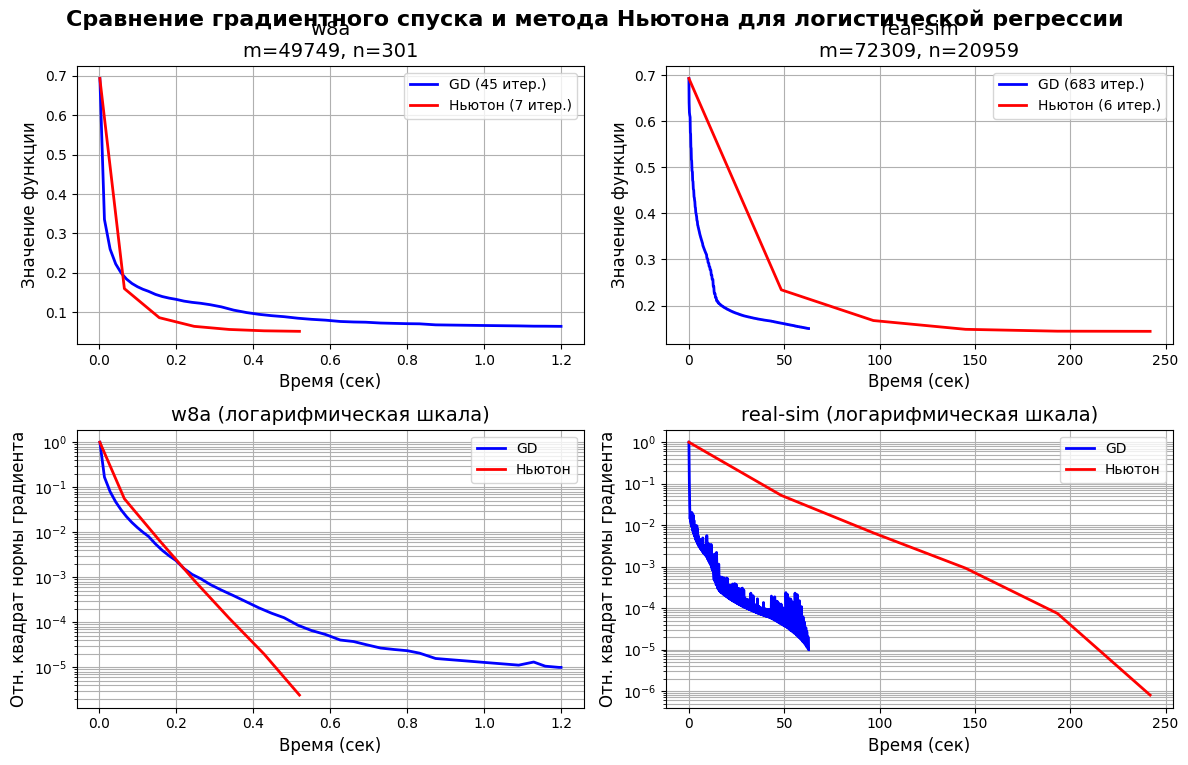

In [47]:
import os
import urllib.request
import bz2
from sklearn.datasets import load_svmlight_file

np.random.seed(42)


def download_and_load_dataset(dataset_name):
    urls = {
        'w8a': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/w8a',
        'real-sim': 'https://www.csie.ntu.edu.tw/~cjlin/libsvmtools/datasets/binary/real-sim.bz2'
    }
    
    filenames = {
        'w8a': 'w8a',
        'real-sim': 'real-sim.bz2'
    }
    
    if not os.path.exists('data'):
        os.makedirs('data')
    
    local_filename = f"data/{filenames[dataset_name]}"
    if not os.path.exists(local_filename):
        urllib.request.urlretrieve(urls[dataset_name], local_filename)
    

    if dataset_name == 'real-sim':
        decompressed_file = "data/real-sim"
        if not os.path.exists(decompressed_file):
            with bz2.open(local_filename, 'rb') as f_in:
                with open(decompressed_file, 'wb') as f_out:
                    f_out.write(f_in.read())
        X, y = load_svmlight_file(decompressed_file)
    else:  # w8a
        X, y = load_svmlight_file(local_filename)
    

    y = np.array([-1 if yi <= 0 else 1 for yi in y])
    
    ones = sparse.csr_matrix(np.ones((X.shape[0], 1)))
    X = sparse.hstack([X, ones]).tocsr()
    
    return X, y

def run_experiment_on_dataset(dataset_name):


    X, y = download_and_load_dataset(dataset_name)
    m, n = X.shape
    
    

    reg_coef = 1.0 / m
    

    oracle = create_log_reg_oracle(X, y, reg_coef)

    x0 = np.zeros(n)
    

    start_time = time.time()
    x_gd, msg_gd, history_gd = gradient_descent(
        oracle, x0, tolerance=1e-5, max_iter=1000,
        line_search_options={'method': 'Wolfe'},
        trace=True
    )
    gd_time = time.time() - start_time
    
    start_time = time.time()
    x_newton, msg_newton, history_newton = newton(
        oracle, x0, tolerance=1e-5, max_iter=100,
        line_search_options={'method': 'Wolfe'},
        trace=True
    )
    newton_time = time.time() - start_time
   
    results = {
        'dataset_name': dataset_name,
        'm': m,
        'n': n,
        'gd': {
            'history': history_gd,
            'time': gd_time,
            'iterations': len(history_gd['time']) if history_gd else 0
        },
        'newton': {
            'history': history_newton,
            'time': newton_time,
            'iterations': len(history_newton['time']) if history_newton else 0
        }
    }
    
    return results


datasets = ['w8a', 'real-sim']
all_results = []

for dataset in datasets:
    results = run_experiment_on_dataset(dataset)
    all_results.append(results)


plt.figure(figsize=(12, 8))

for i, results in enumerate(all_results):
    dataset_name = results['dataset_name']
    m, n = results['m'], results['n']
    

    plt.subplot(2, 2, i+1)
    
    if results['gd']['history']:
        gd_times = np.array(results['gd']['history']['time'])
        gd_funcs = np.array(results['gd']['history']['func'])
        plt.plot(gd_times, gd_funcs, 'b-', linewidth=2, label=f'GD ({results["gd"]["iterations"]} итер.)')
    
    if results['newton']['history']:
        newton_times = np.array(results['newton']['history']['time'])
        newton_funcs = np.array(results['newton']['history']['func'])
        plt.plot(newton_times, newton_funcs, 'r-', linewidth=2, label=f'Ньютон ({results["newton"]["iterations"]} итер.)')
    
    plt.xlabel('Время (сек)', fontsize=12)
    plt.ylabel('Значение функции', fontsize=12)
    plt.title(f'{dataset_name}\nm={m}, n={n}', fontsize=14)
    plt.grid(True)
    plt.legend(fontsize=10)

    plt.subplot(2, 2, i+3)
    
    if results['gd']['history']:
        gd_grad_norms = np.array(results['gd']['history']['grad_norm'])
        gd_rel_grad_sq = (gd_grad_norms / gd_grad_norms[0]) ** 2
        plt.semilogy(gd_times, gd_rel_grad_sq, 'b-', linewidth=2, label='GD')
    
    if results['newton']['history']:
        newton_grad_norms = np.array(results['newton']['history']['grad_norm'])
        newton_rel_grad_sq = (newton_grad_norms / newton_grad_norms[0]) ** 2
        plt.semilogy(newton_times, newton_rel_grad_sq, 'r-', linewidth=2, label='Ньютон')
    
    plt.xlabel('Время (сек)', fontsize=12)
    plt.ylabel('Отн. квадрат нормы градиента', fontsize=12)
    plt.title(f'{dataset_name} (логарифмическая шкала)', fontsize=14)
    plt.grid(True, which="both", ls="-")
    plt.legend(fontsize=10)

plt.suptitle('Сравнение градиентного спуска и метода Ньютона для логистической регрессии', fontsize=16, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()



`Ваш ответ здесь`

# Эксперимент 5: Стратегия выбора длины шага в методе Ньютона



Повторите эксперимент 3 со сравнением стратегий выбора шага на логистической регрессии с модельной выборкой, но для метода Ньютона. Какая стратегия работает лучше всего?



In [ ]:
# your code here

`Ваш ответ здесь`